# Example of Polyhedral Unmixing on the Samson dataset.

##### Add current working directory to system paths

In [1]:
import os, sys

# Add current working directory to system paths
other_repository = os.getcwd()
if other_repository not in sys.path: 
    sys.path.insert(1, other_repository)

##### Import modules and functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.datasets import load_dataset
from src.display  import show_dataset
from src.display  import show_endmember_results, show_abundance_results

from src.metrics  import SAD, RMSE
from src.metrics  import permute_to_GT_M, permute_to_GT_A
from src.metrics  import reorder_C, accuracy_score

from src.unmixing import PolyhedralUnmixingModel

##### Set random seed (if needed)

In [3]:
seed = 1234

import numpy, sklearn
numpy.random.seed(seed)
sklearn.random.seed(seed)

### **1. Load dataset:** [Y] observations, [M] GT endmembers and [A] GT abundances

In [4]:
dataset_name = 'samson'

In [5]:
image, M_gt, A_gt = load_dataset(dataset_name)

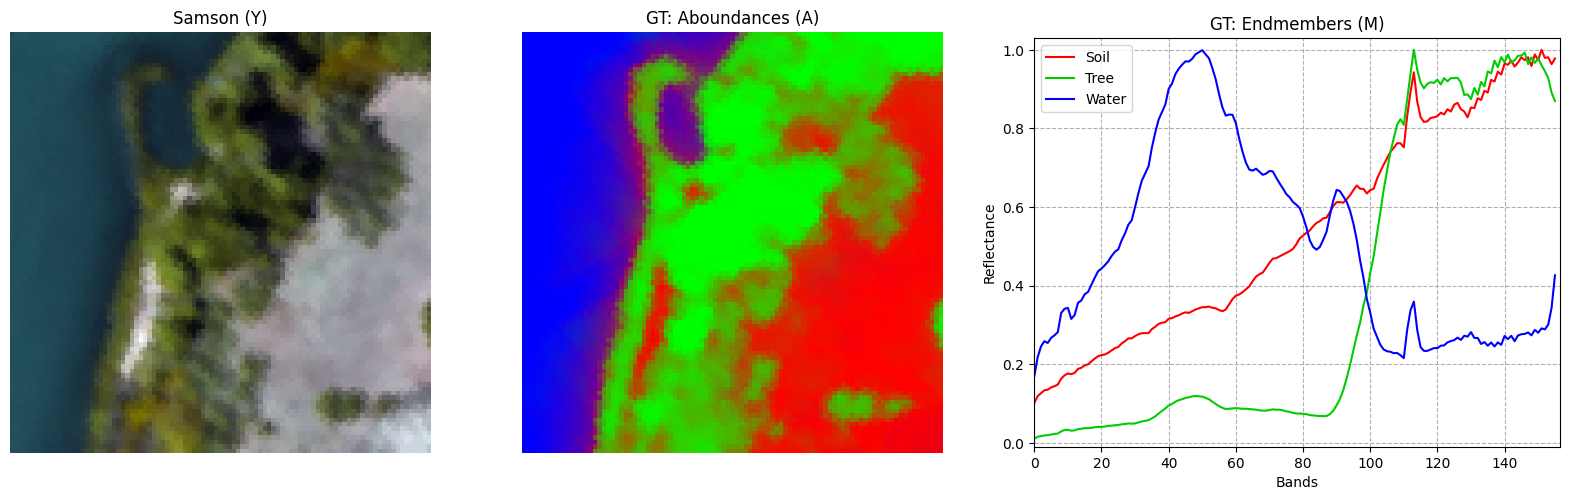

In [6]:
show_dataset(dataset_name, image, M_gt, A_gt)

### **3. Spectral Unmixing:** Polyhedral Unmixing
Use the model to estimate both endmembers (M) and abundances (A) under the assumption of linear independence of the endmembers. See paper [1].
#### **3.1. Set** the number of materials
As no prior **classification map** (pixel **labels**) is given, the model will use a **clustering model** for pixel clustering into **n_materials** clusters. We use here a **Gaussian Mixture Model**.

In [7]:
# Number of endmembers
n_materials = 3

#### **3.2. Initialize** Polyhedral Unmixing model

In [8]:
model = PolyhedralUnmixingModel(
    normalize = True, 
    PCA_ndim = 12, 
    keep_normalized = True, 
    only_python = False, 
    saturation = 0.45, 
    verbose = True
)

#### **3.3. Fit** the model on the given dataset (Y)

In [9]:
model.fit(
    data = image, 
    labels = None, 
    clustering_method = 'GMM', 
    clustering_classes = n_materials, 
    clustering_prop = 0.25, 
    polyhedral_method = 'auto', 
    polyhedral_prop = 0.15, 
    pure_distance_method = 'maxOut'
)

Spectral data - size: (95, 95); bands: 156
* [1/7] (A -> B) Pre-processing input data... Done!
* [2/7] (B -> C) Clustering of input data... Done!
* [3/7] (C -> D) Polyhedral partitioning... Done!
* [4/7] (D -> E) Signed distances computation (C)... Done!
* [5/7] (E -> F) Change of basis in distance space... Done!
* [6/7] (F -> G) Projection onto the probaility simplex... Done!
* [7/7] (FINAL!) Deducing endmembers... Done!


#### **3.4. [Optional] Show** the classification map given by the chosen clustering model after fitting

In [10]:
# Retrieve pixel labels computed by the clustering model
labels = model.get_labels()

# Reshape labels to make a segmented image / classification map
segmented = labels.reshape(*image.shape[:-1]).astype(np.int32)

# Compute the Ground-Truth (GT) dominant-material classification map
C_gt = np.argmax(A_gt, axis=-1).astype(np.int32)

# Permute material positions to align prediction with GT
C_hat = reorder_C(segmented, C_gt)

Accuracy: 0.9167


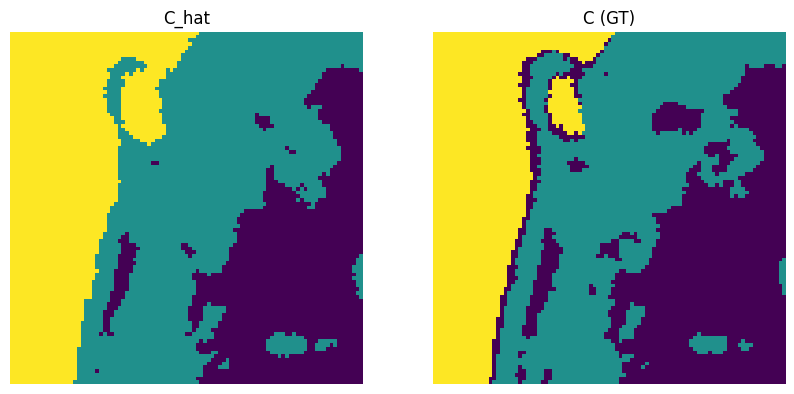

In [11]:
print("Accuracy:", np.round(accuracy_score(C_hat.flatten(), C_gt.flatten()), decimals=4))

fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(C_hat); ax[0].set_axis_off(); ax[0].set_title("C_hat" )
ax[1].imshow(C_gt ); ax[1].set_axis_off(); ax[1].set_title("C (GT)")
plt.show()

#### **3.5. Predict** endmembers (M_hat) and abundances (A_hat) from the given dataset (Y)

In [12]:
M_hat, A_hat = model.predict(data = image)

Spectral data - size: (95, 95); bands: 156
Recovering endmembers and deducing abundances... Done!


#### **3.6. Permute** material positions to align M_hat with M_gt

In [13]:
M_hat, A_hat = permute_to_GT_M(M_hat = M_hat, A_hat = A_hat, M_gt = M_gt)

#### **3.5. Evaluation:** SAD(M) & RMSE(A)
##### 1. Endmember SAD

In [14]:
SAD_classes = []
print("======= SAD =======")
for c in range(M_gt.shape[0]):
    SAD_c = SAD(M_gt[c], M_hat[c], individual=True)
    SAD_classes.append(SAD_c)
    print("Material #{:}: {:.4f}".format(c+1, np.round(SAD_c, decimals=4)))
print("Avg.:        {:.4f}".format(np.round(np.mean(SAD_classes), decimals=4)))

======= SAD =======
Material #1: 0.0168
Material #2: 0.0357
Material #3: 0.0279
Avg.:        0.0268


##### 2. Abundances RMSE

In [15]:
RMSE_classes = []
print("======= RMSE ======")
for c in range(A_gt.shape[-1]):
    RMSE_c = RMSE(A_gt[...,c], A_hat[...,c], individual=True)
    RMSE_classes.append(RMSE_c)
    print("Material #{:}: {:.4f}".format(c+1, np.round(RMSE_c, decimals=4)))
print("Avg.:        {:.4f}".format(np.round(np.mean(RMSE_classes), decimals=4)))

======= RMSE ======
Material #1: 0.0383
Material #2: 0.0281
Material #3: 0.0301
Avg.:        0.0322


#### **3.6 Show results:** [M] Endmembers & [A] Abundances
##### 1. Endmembers

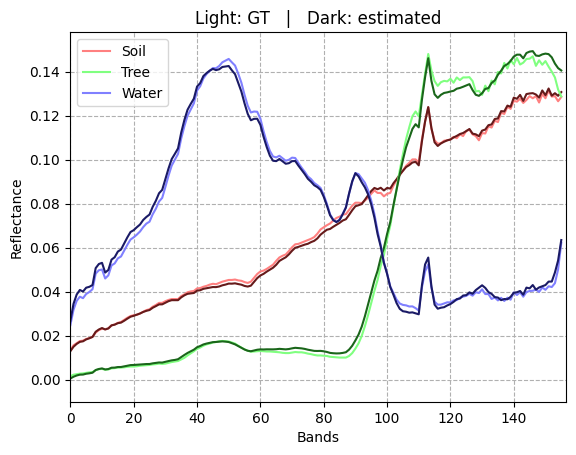

In [16]:
show_endmember_results(dataset_name, M_gt, M_hat)

##### 2. Abundance maps

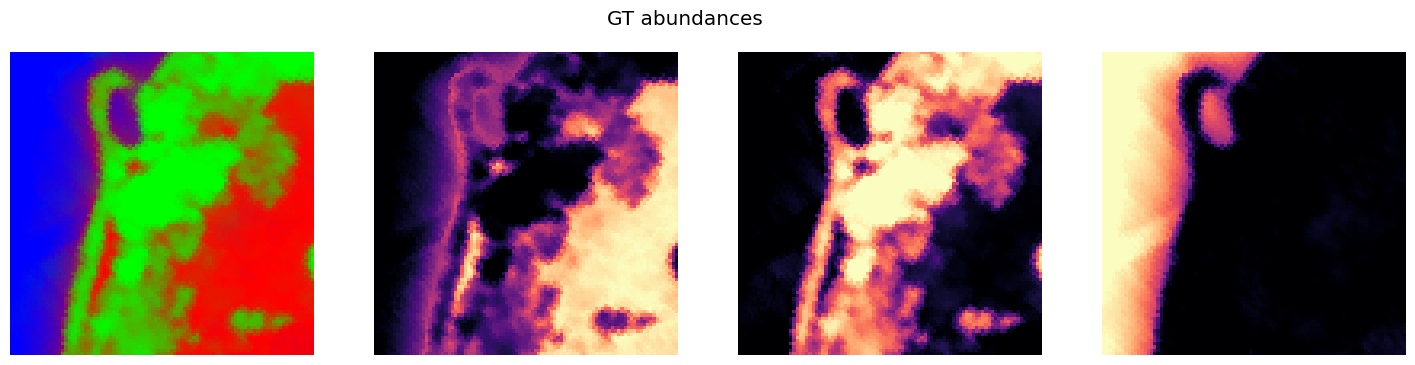

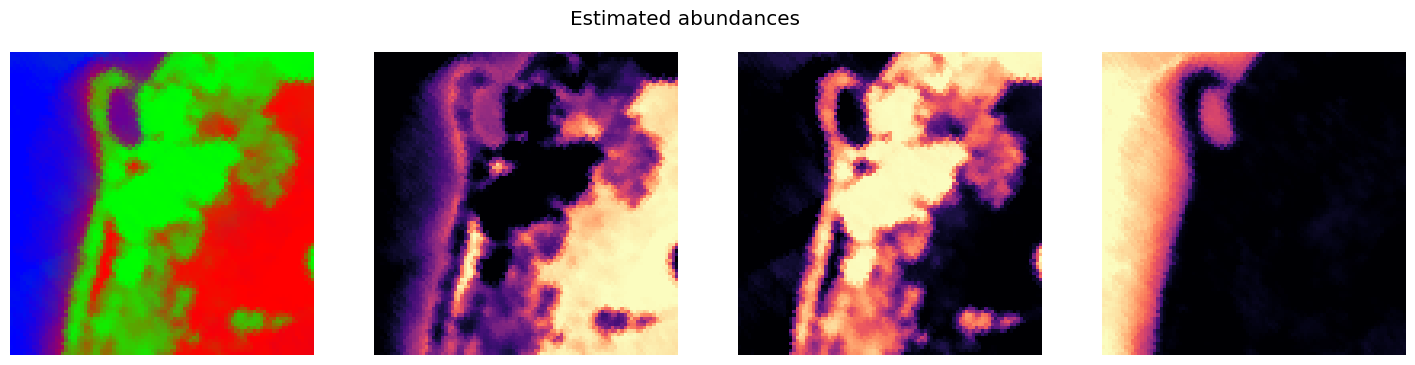

In [17]:
show_abundance_results(dataset_name, A_gt, A_hat)

### **4. Abundance Estimation:** Initial Abundance Estimate of Polyhedral Model
Use the model to estimate the abundances (A) via its initial abundance estimate, whether the endmembers are linearly independent or not. See paper [2].
#### **4.1. [Optional] Set** saturation hyperparameter to default value
The Polyhedral Unmixing model can also be (re-)initialized if needed.

In [18]:
# Set to the default value of 2/5
model.saturation = 2/5

#### **4.2. [Optional] (Re-)fit** the model on the given dataset (Y) for initial abundance estimate

In [19]:
refit_model:bool = False

if refit_model:
    
    n_materials = 3 # number of materials

    model.fit_initial(
        data = image, 
        labels = None, 
        clustering_method = 'GMM', 
        clustering_classes = n_materials, 
        clustering_prop = 0.25, 
        polyhedral_method = 'auto', 
        polyhedral_prop = 0.15, 
        pure_distance_method = 'maxOut'
    )

#### **4.3. Predict** initial abundances (A_init) from the given dataset (Y)

In [20]:
A_init = model.predict_initial_abundances(data = image)

Spectral data - size: (95, 95); bands: 156
* [1/4] (A -> B) Pre-processing input data... Done!
* [2/4] (D -> E) Signed distances computation (C)... Done!
* [3/4] (E -> F) Change of basis in distance space... Done!
* [4/4] (F -> G) Projection onto the probaility simplex... Done!


#### **4.4. Permute** material positions to align A_init with A_gt

In [21]:
A_init = permute_to_GT_A(M_hat = None, A_hat = A_init, A_gt = A_gt)

#### **4.5. Evaluation:** Initial abundance RMSE

In [22]:
RMSE_classes = []
print("======= RMSE ======")
for c in range(A_gt.shape[-1]):
    RMSE_c = RMSE(A_gt[...,c], A_init[...,c], individual=True)
    RMSE_classes.append(RMSE_c)
    print("Material #{:}: {:.4f}".format(c+1, np.round(RMSE_c, decimals=4)))
print("Avg.:        {:.4f}".format(np.round(np.mean(RMSE_classes), decimals=4)))

======= RMSE ======
Material #1: 0.0344
Material #2: 0.0252
Material #3: 0.0347
Avg.:        0.0315


#### **4.6 Show results:** [A] Abundances maps

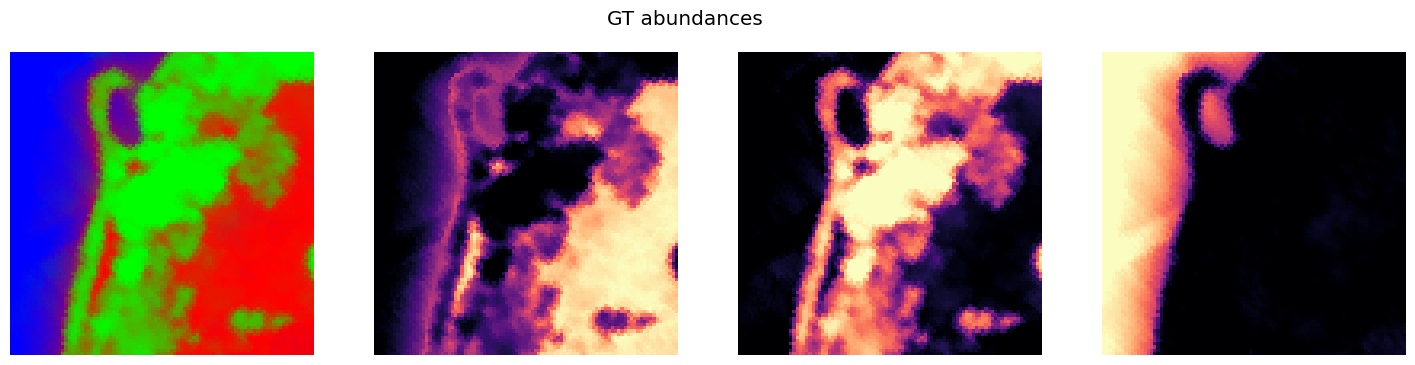

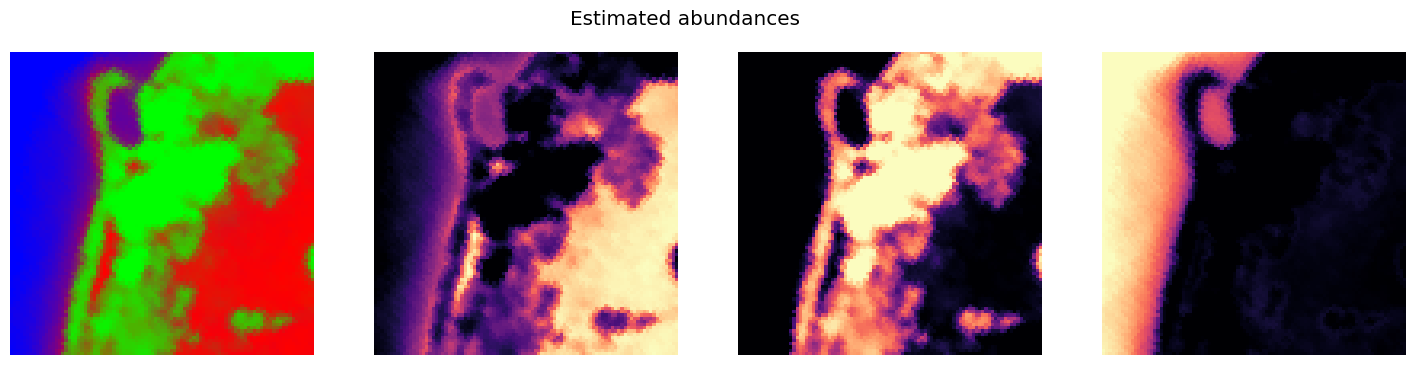

In [23]:
show_abundance_results(dataset_name, A_gt, A_init)